In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [2]:
df=pd.read_csv(r'D:\AI_Public_Health_Project\data\kenya_public_health_vulnerability.csv')

In [3]:
df.head()

,County,Population,Population_Density,Poverty_Rate,Health_Facilities,Doctors_per_10000,Immunization_Coverage,Clean_Water_Access,Maternal_Mortality,Under5_Mortality,Malnutrition_Rate,HIV_Prevalence,Malaria_Prevalence,Unemployment_Rate,Vulnerability_Level,Vulnerability_Encoded,Vulnerability_Score,Latitude,Longitude
0,Mombasa,211911,1675,53,129,2.0,92,49,473,89,8,2.2,21,5,High,0,28.85,-4.0435,39.6682
1,Kwale,3809961,1685,44,150,9.5,52,90,160,23,35,11.6,24,19,Medium,2,32.15,-4.1816,39.4606
2,Kilifi,3310152,4987,24,294,6.8,70,46,285,35,14,5.9,40,17,Low,1,30.60,-3.5107,39.9093
3,Tana River,403085,4986,79,44,10.4,62,65,352,52,13,7.3,1,20,Very High,3,38.40,-1.6518,40.0287
4,Lamu,1061972,4935,28,159,7.1,83,91,297,78,18,12.0,29,9,Medium,2,18.70,-2.2717,40.9020


In [4]:
df.shape

(47, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   County                 47 non-null     str    
 1   Population             47 non-null     int64  
 2   Population_Density     47 non-null     int64  
 3   Poverty_Rate           47 non-null     int64  
 4   Health_Facilities      47 non-null     int64  
 5   Doctors_per_10000      47 non-null     float64
 6   Immunization_Coverage  47 non-null     int64  
 7   Clean_Water_Access     47 non-null     int64  
 8   Maternal_Mortality     47 non-null     int64  
 9   Under5_Mortality       47 non-null     int64  
 10  Malnutrition_Rate      47 non-null     int64  
 11  HIV_Prevalence         47 non-null     float64
 12  Malaria_Prevalence     47 non-null     int64  
 13  Unemployment_Rate      47 non-null     int64  
 14  Vulnerability_Level    47 non-null     str    
 15  Vulnerability_Encod

In [6]:
df.isnull().sum()

County                   0
Population               0
Population_Density       0
Poverty_Rate             0
Health_Facilities        0
Doctors_per_10000        0
Immunization_Coverage    0
Clean_Water_Access       0
Maternal_Mortality       0
Under5_Mortality         0
Malnutrition_Rate        0
HIV_Prevalence           0
Malaria_Prevalence       0
Unemployment_Rate        0
Vulnerability_Level      0
Vulnerability_Encoded    0
Vulnerability_Score      0
Latitude                 0
Longitude                0
dtype: int64

In [7]:
df.describe()

,Population,Population_Density,Poverty_Rate,Health_Facilities,Doctors_per_10000,Immunization_Coverage,Clean_Water_Access,Maternal_Mortality,Under5_Mortality,Malnutrition_Rate,HIV_Prevalence,Malaria_Prevalence,Unemployment_Rate,Vulnerability_Encoded,Vulnerability_Score,Latitude,Longitude
count,4.700000e+01,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.00000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,2.206469e+06,3682.255319,51.829787,183.574468,6.527660,72.872340,64.659574,323.595745,53.872340,19.723404,9.253191,25.12766,16.425532,1.787234,32.564894,-0.380823,36.800745
std,1.351398e+06,2119.963653,19.118986,88.919784,3.422541,13.591265,20.965061,147.214670,20.091765,8.203133,4.343403,13.16553,7.856719,1.178359,6.297100,1.601343,1.963729
min,2.025880e+05,186.000000,18.000000,30.000000,1.200000,50.000000,30.000000,103.000000,23.000000,5.000000,2.200000,1.00000,5.000000,0.000000,18.050000,-4.181600,34.111500
25%,1.008806e+06,1860.000000,36.000000,109.500000,3.450000,62.000000,47.000000,180.000000,36.500000,13.000000,6.000000,13.50000,9.000000,1.000000,30.225000,-1.129650,35.119350
50%,2.157831e+06,4129.000000,55.000000,162.000000,6.200000,70.000000,65.000000,324.000000,51.000000,19.000000,8.900000,26.00000,17.000000,2.000000,32.450000,-0.367000,36.781900
75%,3.418890e+06,5639.000000,67.000000,267.500000,9.600000,85.000000,86.000000,439.000000,72.000000,26.500000,11.600000,37.50000,22.500000,3.000000,37.150000,0.410550,37.769450
max,4.980895e+06,6795.000000,79.000000,320.000000,12.000000,94.000000,95.000000,574.000000,89.000000,35.000000,18.000000,45.00000,30.000000,3.000000,44.350000,3.936600,41.867000


In [8]:
df['Vulnerability_Level'].value_counts()

Vulnerability_Level
Very High    17
Medium       14
High         11
Low           5
Name: count, dtype: int64

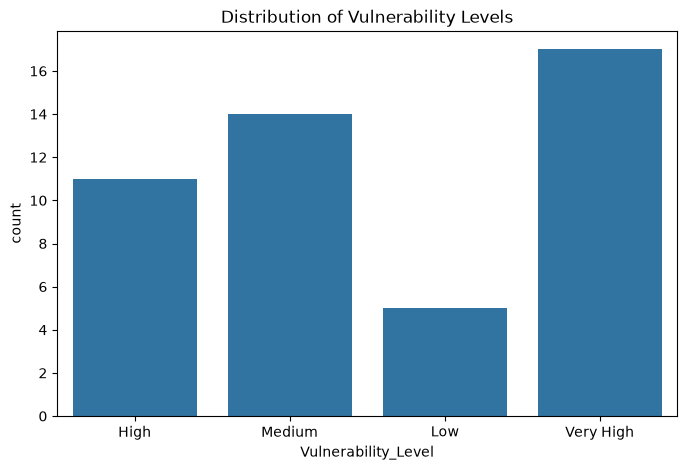

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Vulnerability_Level'
)

plt.title('Distribution of Vulnerability Levels')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Vulnerability_Encoded'] = encoder.fit_transform(
    df['Vulnerability_Level']
)

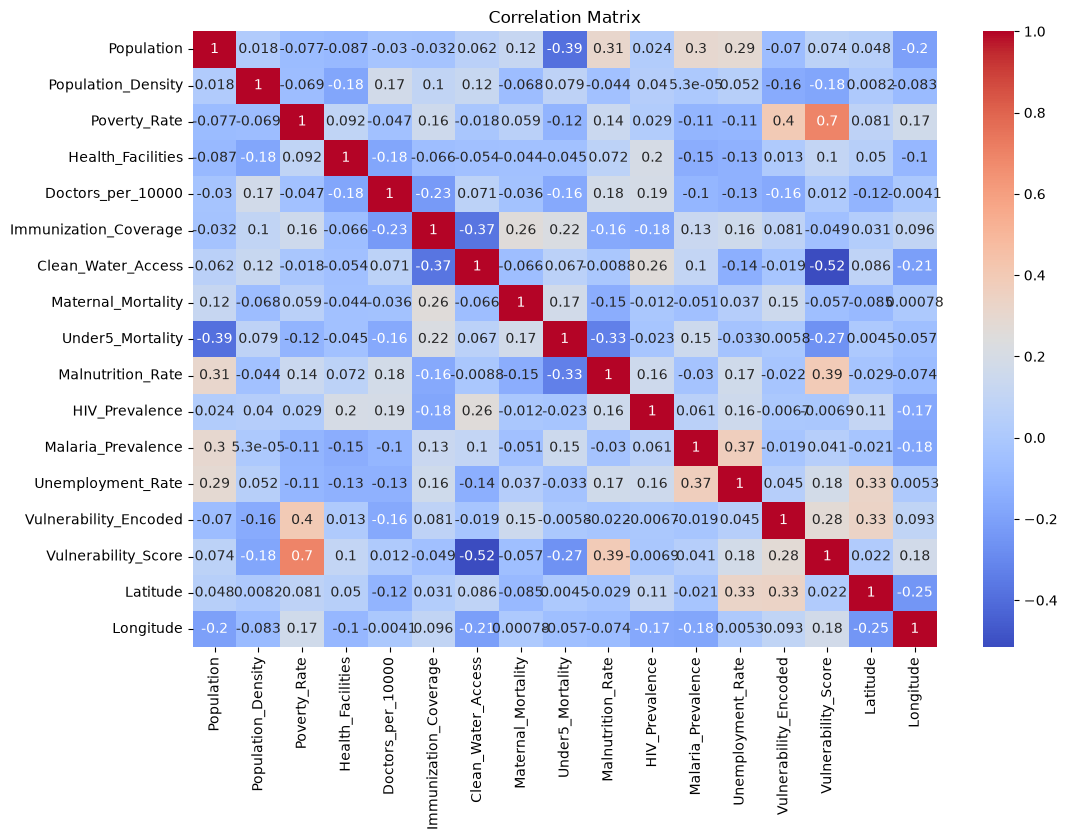

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

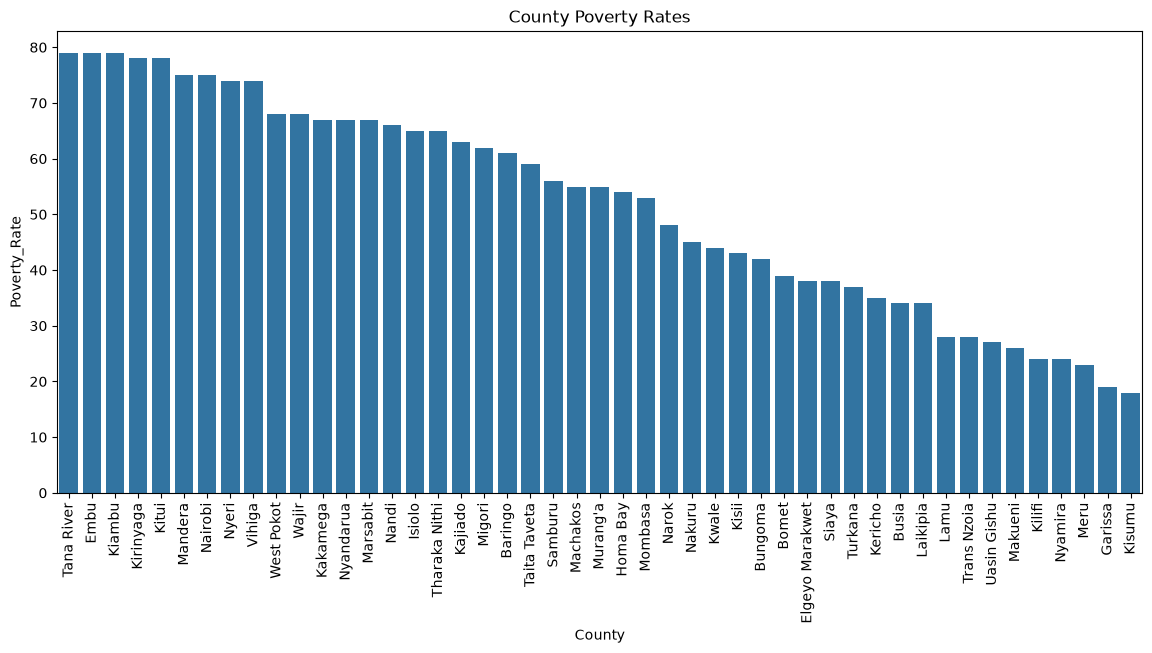

In [12]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df.sort_values(
        'Poverty_Rate',
        ascending=False
    ),
    x='County',
    y='Poverty_Rate'
)

plt.xticks(rotation=90)

plt.title(
    'County Poverty Rates'
)

plt.show()